In [1]:
from pedalboard import Pedalboard
from pedalboard import Chorus, Distortion, Phaser # guitar-style effects
from pedalboard import Compressor # dynamic range effects
from pedalboard import Reverb # spacial effects 

In [2]:
import matplotlib.pyplot as plt
import math
import numpy as np 
import torch
import random

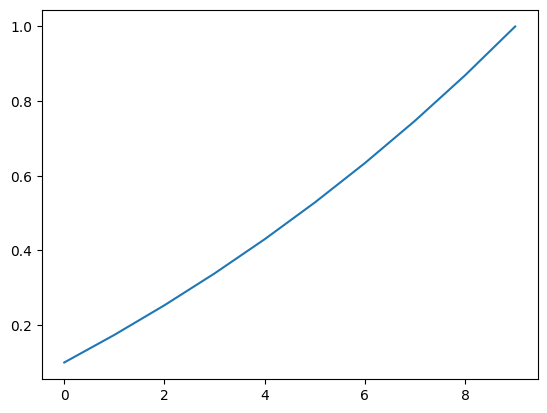

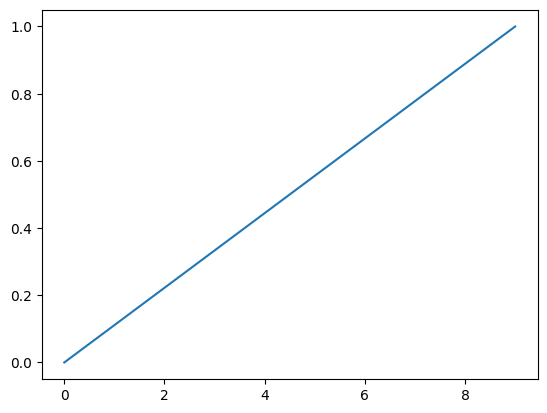

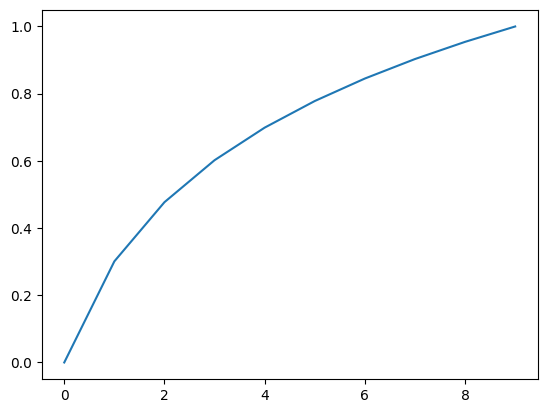

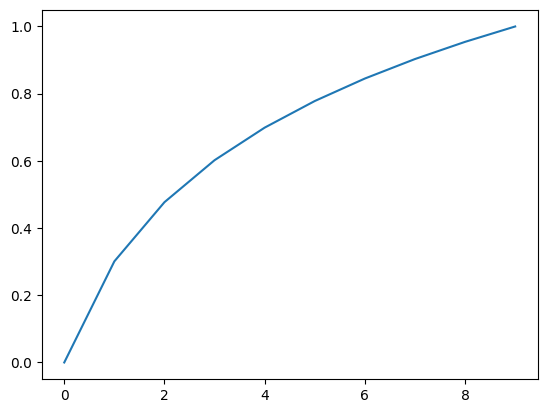

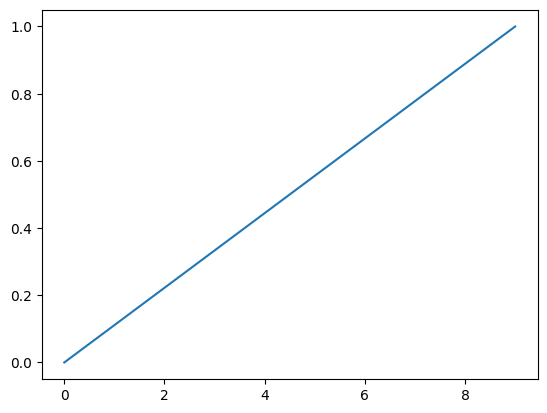

In [3]:
def pow_range(lower, upper, step_size): 
    return np.power(
        upper - lower + 1,
        np.arange(step_size) / (step_size - 1)) + lower - 1
    
def lin_range(lower, upper, step_size): 
    return np.linspace(start=lower, stop=upper, num=step_size)

def log_range(lower, upper, step_size): 
    b = (upper - lower) / math.log(step_size)
    return np.log(np.arange(step_size)+1) * b + lower
    
test1 = {"min": 0.1, "max": 1.0, "arange": pow_range}
test2 = {"min": 0.0, "max": 1.0, "arange": lin_range}
test3 = {"min": 0.0, "max": 1.0, "arange": log_range}
test4 = {"min": 0.0, "max": 1.0, "arange": log_range}
test5 = {"min": 0.0, "max": 1.0, "arange": lin_range}

step_size = 10

for test in [test1, test2, test3, test4, test5]:  
    y = test["arange"](test["min"], test["max"], step_size)
   
    plt.plot(np.arange(step_size), y)
    
    plt.show()

In [4]:
step_size = 10
pedal_dict = {
    "compressor": {
        "pedal": Compressor, 
        "params": {
            "threshold_db": {"min": -60, "max": 10,  "arange": pow_range},
            "ratio":        {"min": 1.1, "max": 20,  "arange": log_range},
            "attack_ms":    {"min": 1,   "max": 100, "arange": log_range},
            "release_ms":   {"min": 40,  "max": 400, "arange": log_range}
        },
        "dropout": 0.5
    },
    "distortion": {
        "pedal": Distortion,
        "params": {
            "drive_db": {"min": 0, "max": 45, "arange": log_range}
        },
        
        "dropout": 0.5
    },
    "chorus": {
        "pedal": Chorus, 
        "params": {
            "rate_hz" :        {"min": 0.1, "max": 8.0,  "arange": log_range}, 
            "centre_delay_ms": {"min": 5,   "max": 25,   "arange": lin_range}, 
            "depth" :          {"min": 0.01, "max": 0.25, "arange": lin_range},
            "feedback" :       {"min": 0.0,  "max": 0.4,  "arange": lin_range},
            "mix" :            {"min": 0.0,  "max": 1.0,  "arange": lin_range} 
        },
        "dropout": 0.5
    },
    "phaser": {
        "pedal": Phaser, 
        "params": {
            "rate_hz":             {"min": 0.1, "max": 5.0,  "arange": log_range}, 
            "depth":               {"min": 0.1, "max": 1.0,  "arange": lin_range}, 
            "centre_frequency_hz": {"min": 100, "max": 2000, "arange": log_range}, 
            "feedback":            {"min": 0.0, "max": 0.6,  "arange": lin_range}, 
            "mix":                 {"min": 0.5, "max": 1.0,  "arange": lin_range}  
        },
        "dropout": 0.5
    },
    "reverb": {
        "pedal": Reverb,
        "params": {
            "room_size": {"min": 0.1, "max": 1.0, "arange": pow_range}, 
            "damping":   {"min": 0.0, "max": 1.0, "arange": lin_range}, 
            "wet_level": {"min": 0.0, "max": 1.0, "arange": log_range}, 
            "dry_level": {"min": 0.0, "max": 1.0, "arange": log_range}, 
            "width":     {"min": 0.0, "max": 1.0, "arange": lin_range}  
        },
        "dropout": 0.5
    }
}

In [50]:
def create_bins(pedal_dict, step_size):
    bin_dict = {}
    for effect in pedal_dict.keys(): 
        effect_dict = pedal_dict[effect] 
        params_dict = effect_dict["params"] 
        effect_bin_dict = {}
        params_bin_dict = {}

        effect_bin_dict["pedal"] = effect_dict["pedal"]

        for param in params_dict: 
            param_dict = params_dict[param]
            bins = param_dict["arange"](param_dict["min"], param_dict["max"], step_size)
            params_bin_dict[param] = bins

        effect_bin_dict["params"] = params_bin_dict
        effect_bin_dict["dropout"] = effect_dict["dropout"]

        bin_dict[effect] = effect_bin_dict
    bin_dict["step_size"] = step_size
    return bin_dict

pedal_bin_dict = create_bins(pedal_dict, step_size)

In [67]:
def get_pedal_board(pedal_dict, shuffle=True):
    board = []
    board_string = []
    step_size = pedal_dict["step_size"]

    for name, param_dict in pedal_dict.items(): 
        if name == "step_size": 
            continue
        dropout = param_dict['dropout']
        
        if random.random() > dropout:  
            pedal_class = param_dict['pedal']
            params = param_dict['params']
            
            args = {}
            for param, bins in params.items(): 
                i = random.randint(0, step_size - 1)
                args[param] = bins[i] 
            board_string.append(" ".join([name + ":" + param + ":" + str(choice) for param, choice in args.items()]))
            board.append(pedal_class(**args))
    if shuffle: 
        combined = list(zip(board, board_string))
        random.shuffle(combined)
        board, board_string = zip(*combined)

    board = Pedalboard(board)
        
    return board, list(board_string)

In [93]:
get_pedal_board(pedal_bin_dict)

(<Pedalboard with 3 plugins: [<pedalboard.Chorus rate_hz=3.86926 depth=0.116667 centre_delay_ms=25 feedback=0.222222 mix=0.777778 at 0xe450550>, <pedalboard.Distortion drive_db=42.9409 at 0xe907040>, <pedalboard.Reverb room_size=0.634037 damping=0.222222 wet_level=1 dry_level=0.60206 width=0 freeze_mode=0 at 0xe2a3070>]>,
 ['chorus:rate_hz:3.8692579122853332 chorus:centre_delay_ms:25.0 chorus:depth:0.11666666666666665 chorus:feedback:0.22222222222222224 chorus:mix:0.7777777777777777',
  'distortion:drive_db:42.94091292476961',
  'reverb:room_size:0.6340366443789158 reverb:damping:0.2222222222222222 reverb:wet_level:0.9999999999999999 reverb:dry_level:0.6020599913279623 reverb:width:0.0'])

# new tokenization scheme 

Instead of having set bins, make it more flexible by allowing each parameter to be scaled in different ways 

assume that the parameters are all continuous for now 

on actual pedals, many parameters are controlled by circular knobs. using this fact, instead of having separate tokens for each effects, we can encode the parameters as displacement angle. 

I need to think about this more, but how would i make the model spit out sequence of discrete tokens as well as continuous values? have a decoder that's dedicated to predicting the sequence of tokens and have another decoder that's responsible for predicting the parameters
- The decoder that predicts sequence of tokens will probably be a transformer-based decoder, whose maximum length should be the total number of used effects
- The decoder that predicts sequence of tokens can be an